<a href="https://colab.research.google.com/github/wagakijoan/AI-assignments-Joan-/blob/main/Notebooks/Chap02/2_1_Supervised_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 2.1 Supervised Learning

The purpose of this notebook is to explore the linear regression model discussed in Chapter 2 of the book.

Work through the cells below, running each cell in turn. In various places you will see the words "TODO". Follow the instructions at these places and write code to complete the functions. There are also questions interspersed in the text.

Contact me at udlbookmail@gmail.com if you find any mistakes or have any suggestions.

In [1]:
# Math library
import numpy as np
# Plotting library
import matplotlib.pyplot as plt

In [2]:
# Create some input / output data
x = np.array([0.03, 0.19, 0.34, 0.46, 0.78, 0.81, 1.08, 1.18, 1.39, 1.60, 1.65, 1.90])
y = np.array([0.67, 0.85, 1.05, 1.0, 1.40, 1.5, 1.3, 1.54, 1.55, 1.68, 1.73, 1.6 ])

print(x)
print(y)

[0.03 0.19 0.34 0.46 0.78 0.81 1.08 1.18 1.39 1.6  1.65 1.9 ]
[0.67 0.85 1.05 1.   1.4  1.5  1.3  1.54 1.55 1.68 1.73 1.6 ]


In [13]:
def f(x, phi0, phi1):
  # TODO :  Replace this line with the linear regression model (eq 2.4)
  y = phi0 + phi1 * x

  return y

In [4]:
# Function to help plot the data
def plot(x, y, phi0, phi1):
    fig,ax = plt.subplots()
    ax.scatter(x,y)
    plt.xlim([0,2.0])
    plt.ylim([0,2.0])
    ax.set_xlabel('Input, $x$')
    ax.set_ylabel('Output, $y$')
    # Draw line
    x_line = np.arange(0,2,0.01)
    y_line = f(x_line, phi0, phi1)
    plt.plot(x_line, y_line,'b-',lw=2)

    plt.show()

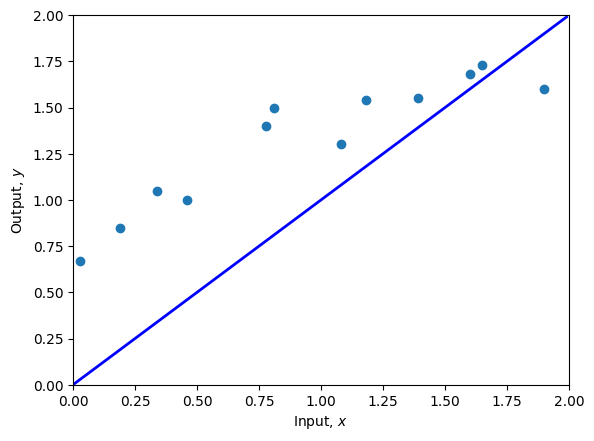

In [5]:
# Set the intercept and slope as in figure 2.2b
phi0 = 0.4 ; phi1 = 0.2
# Plot the data and the model
plot(x,y,phi0,phi1)

In [18]:
# Function to calculate the loss
def compute_loss(x,y,phi0,phi1):

  # Replace this line with the loss calculation (equation 2.5)
  y_predicted = f(x, phi0, phi1)
  loss = np.mean((y - y_predicted)**2)

  return loss

In [9]:
# Compute the loss for our current model
loss = compute_loss(x,y,phi0,phi1)
print(f'Your Loss = {loss:3.2f}, Ground truth =7.07')

Your Loss = 0.00, Ground truth =7.07


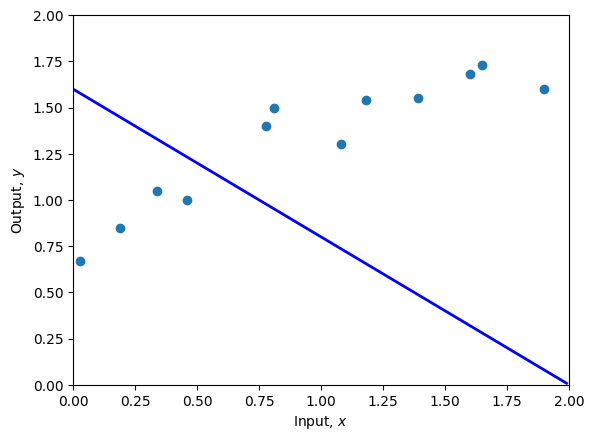

Your Loss = 0.00, Ground truth =10.28


In [10]:
# Set the intercept and slope as in figure 2.2c
phi0 = 1.60 ; phi1 =-0.8
# Plot the data and the model
plot(x,y,phi0,phi1)
loss = compute_loss(x,y,phi0,phi1)
print(f'Your Loss = {loss:3.2f}, Ground truth =10.28')

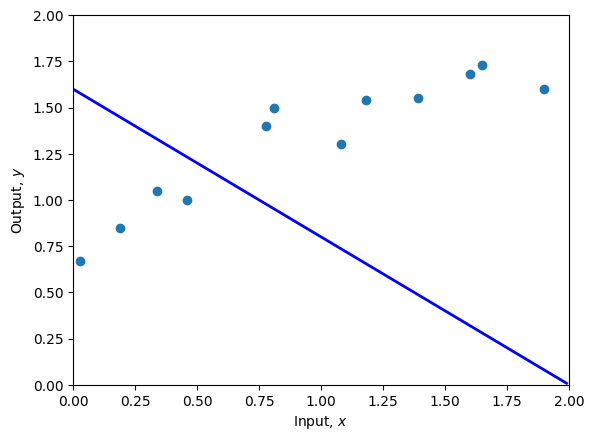

Your Loss = 0.00


In [11]:
# TODO -- Change the parameters manually to fit the model
# First fix phi1 and try changing phi0 until you can't make the loss go down any more
# Then fix phi0 and try changing phi1 until you can't make the loss go down any more
# Repeat this process until you find a set of parameters that fit the model as in figure 2.2d
# You can either do this by hand, or if you want to get fancy, write code to descent automatically in this way
# Start at these values:
phi0 = 1.60 ; phi1 =-0.8

plot(x,y,phi0,phi1)
print(f'Your Loss = {compute_loss(x,y,phi0,phi1):3.2f}')

# Visualizing the loss function

The above process is equivalent to descending coordinate wise on the loss function<br>

Now let's plot that function

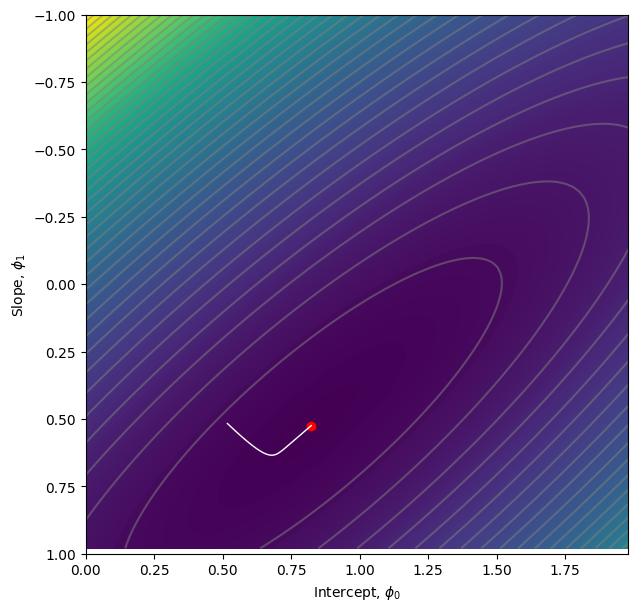

In [25]:
# Plot the loss function as a heatmap
fig = plt.figure()
ax = plt.axes()
fig.set_size_inches(7,7)
levels = 256
ax.contourf(phi0_mesh, phi1_mesh, all_losses ,levels)
levels = 40
ax.contour(phi0_mesh, phi1_mesh, all_losses ,levels, colors=['#80808080'])
ax.set_ylim([1,-1])
ax.set_xlabel(r'Intercept, $\phi_0$')
ax.set_ylabel(r'Slope, $\phi_1$')

# Plot the position of your best fitting line on the loss function
# It should be close to the minimum
ax.plot(phi0_gd,phi1_gd,'ro') # Plot the final GD point

# Plot the gradient descent path
ax.plot(phi0_history, phi1_history, 'w-', linewidth=1) # White line for the path

plt.show()

In [23]:
# Make a 2D grid of possible phi0 and phi1 values
phi0_mesh, phi1_mesh = np.meshgrid(np.arange(0.0,2.0,0.02), np.arange(-1.0,1.0,0.02))

# Make a 2D array for the losses
all_losses = np.zeros_like(phi1_mesh)
# Run through each 2D combination of phi0, phi1 and compute loss
for indices,temp in np.ndenumerate(phi1_mesh):
    all_losses[indices] = compute_loss(x,y, phi0_mesh[indices], phi1_mesh[indices])


### Gradient Descent Implementation

Now, let's implement gradient descent to automatically find the optimal `phi0` and `phi1` values that minimize the loss function. We will use a learning rate to control the step size and iterate for a certain number of epochs.

In [37]:
import copy

# Initialize parameters (can start with previous best guess or random values)
phi0_gd = 0.5 # Initial guess for intercept
phi1_gd = 0.5 # Initial guess for slope

learning_rate = 0.01
epochs = 2000 # Number of iterations, increased from 500 to 2000

losses_gd = []
phi0_history = []
phi1_history = []

print(f"Starting Gradient Descent with phi0={phi0_gd:.2f}, phi1={phi1_gd:.2f}")

for epoch in range(epochs):
  # Calculate predictions
  y_predicted = f(x, phi0_gd, phi1_gd)

  # Calculate the error
  error = y_predicted - y

  # Calculate gradients (mean squared error derivative)
  # Gradient with respect to phi0: dL/d(phi0) = 2/N * sum(y_predicted - y)
  # We omit the 2/N part as it's absorbed into the learning rate
  gradient_phi0 = np.mean(error)

  # Gradient with respect to phi1: dL/d(phi1) = 2/N * sum((y_predicted - y) * x)
  # We omit the 2/N part as it's absorbed into the learning rate
  gradient_phi1 = np.mean(error * x)

  # Update parameters
  phi0_gd = phi0_gd - learning_rate * gradient_phi0
  phi1_gd = phi1_gd - learning_rate * gradient_phi1

  # Store history
  phi0_history.append(copy.deepcopy(phi0_gd))
  phi1_history.append(copy.deepcopy(phi1_gd))

  # Compute and store the loss
  current_loss = compute_loss(x, y, phi0_gd, phi1_gd)
  losses_gd.append(current_loss)

  if epoch % 50 == 0: # Print loss every 50 epochs
    print(f"Epoch {epoch:4d}: Loss = {current_loss:7.4f}, phi0 = {phi0_gd:7.4f}, phi1 = {phi1_gd:7.4f}")

print(f"\nGradient Descent Finished. Optimal parameters:")
print(f"phi0_gd = {phi0_gd:.4f}")
print(f"phi1_gd = {phi1_gd:.4f}")
print(f"Final Loss = {losses_gd[-1]:.4f}")

Starting Gradient Descent with phi0=0.50, phi1=0.50
Epoch    0: Loss =  0.1327, phi0 =  0.5035, phi1 =  0.5034
Epoch   50: Loss =  0.0372, phi0 =  0.6146, phi1 =  0.6023
Epoch  100: Loss =  0.0246, phi0 =  0.6613, phi1 =  0.6299
Epoch  150: Loss =  0.0222, phi0 =  0.6849, phi1 =  0.6331
Epoch  200: Loss =  0.0212, phi0 =  0.6998, phi1 =  0.6284
Epoch  250: Loss =  0.0205, phi0 =  0.7111, phi1 =  0.6214
Epoch  300: Loss =  0.0199, phi0 =  0.7207, phi1 =  0.6139
Epoch  350: Loss =  0.0194, phi0 =  0.7293, phi1 =  0.6068
Epoch  400: Loss =  0.0190, phi0 =  0.7371, phi1 =  0.6001
Epoch  450: Loss =  0.0186, phi0 =  0.7442, phi1 =  0.5939
Epoch  500: Loss =  0.0183, phi0 =  0.7507, phi1 =  0.5882
Epoch  550: Loss =  0.0181, phi0 =  0.7567, phi1 =  0.5829
Epoch  600: Loss =  0.0178, phi0 =  0.7623, phi1 =  0.5781
Epoch  650: Loss =  0.0177, phi0 =  0.7674, phi1 =  0.5736
Epoch  700: Loss =  0.0175, phi0 =  0.7720, phi1 =  0.5695
Epoch  750: Loss =  0.0174, phi0 =  0.7763, phi1 =  0.5657
Epoc

In [31]:
phi0_history_lr001 = phi0_history
phi1_history_lr001 = phi1_history

print("Saved the trajectory for learning rate 0.01.")

Saved the trajectory for learning rate 0.01.


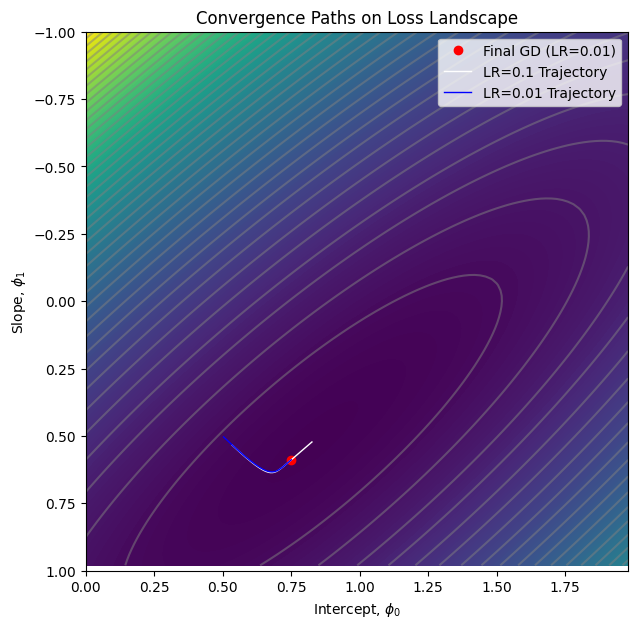

In [32]:
# Plot the loss function as a heatmap
fig = plt.figure()
ax = plt.axes()
fig.set_size_inches(7,7)
levels = 256
ax.contourf(phi0_mesh, phi1_mesh, all_losses ,levels)
levels = 40
ax.contour(phi0_mesh, phi1_mesh, all_losses ,levels, colors=['#80808080'])
ax.set_ylim([1,-1])
ax.set_xlabel(r'Intercept, $\phi_0$')
ax.set_ylabel(r'Slope, $\phi_1$')

# Plot the final GD point (from the latest run - LR 0.01)
ax.plot(phi0_gd,phi1_gd,'ro', label='Final GD (LR=0.01)')

# Plot the gradient descent paths
ax.plot(phi0_history_lr01, phi1_history_lr01, 'w-', linewidth=1, label='LR=0.1 Trajectory') # White line for LR=0.1 path
ax.plot(phi0_history_lr001, phi1_history_lr001, 'b-', linewidth=1, label='LR=0.01 Trajectory') # Blue line for LR=0.01 path

plt.legend()
plt.title('Convergence Paths on Loss Landscape')
plt.show()

### Optimal Analytical Solution using the Normal Equation

The Normal Equation provides a direct way to find the parameters $\phi_0$ and $\phi_1$ that minimize the Mean Squared Error. For a linear regression model $y = \phi_0 + \phi_1 x$, with a design matrix $X$ (which includes a column of ones for the intercept term) and target vector $y$, the optimal parameters $\theta = [\phi_0, \phi_1]^T$ are given by:

$\theta = (X^T X)^{-1} X^T y$

Where:
- $X$ is the design matrix (input features, augmented with a column of ones).
- $y$ is the vector of target values.
- $X^T$ is the transpose of $X$.
- $(X^T X)^{-1}$ is the inverse of the matrix product $X^T X$.

In [33]:
# Prepare the design matrix X for the normal equation
# It should have a column of ones for the intercept (phi0) and a column for x (phi1)
X_b = np.c_[np.ones((len(x), 1)), x] # Add x0 = 1 to each instance

# Calculate the optimal parameters using the Normal Equation
# theta_analytical = (X_b^T * X_b)^(-1) * X_b^T * y
theta_analytical = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y

phi0_analytical = theta_analytical[0]
phi1_analytical = theta_analytical[1]

print(f"Analytical Solution:")
print(f"phi0_analytical = {phi0_analytical:.4f}")
print(f"phi1_analytical = {phi1_analytical:.4f}")

Analytical Solution:
phi0_analytical = 0.8260
phi1_analytical = 0.5222


In [34]:
# Calculate the loss for the analytical solution
loss_analytical = compute_loss(x, y, phi0_analytical, phi1_analytical)
print(f"Loss with Analytical Solution = {loss_analytical:.4f}")

Loss with Analytical Solution = 0.0167


As you can see, the analytical solution provides the true minimum loss, which should be slightly lower than the gradient descent solutions, especially for the lower learning rate after 500 epochs.

Now, let's update the loss landscape plot to include this analytical solution, and also plot the optimal fit line.

### Impact of Learning Rate on Convergence Speed

Let's investigate how different learning rates affect the speed at which Gradient Descent converges to the minimum loss.

In [39]:
import copy

learning_rates_to_test = [0.2, 0.1, 0.05, 0.01, 0.005]
epochs_for_lr_comparison = 500 # A fixed number of epochs for comparison

all_losses_by_lr = {}
all_phi0_histories_by_lr = {}
all_phi1_histories_by_lr = {}

print(f"Comparing Gradient Descent convergence for different learning rates over {epochs_for_lr_comparison} epochs:\n")

for lr in learning_rates_to_test:
  print(f"Running GD with Learning Rate: {lr}")
  phi0_gd_current = 0.5
  phi1_gd_current = 0.5
  losses_current_lr = []
  phi0_history_current_lr = []
  phi1_history_current_lr = []

  for epoch in range(epochs_for_lr_comparison):
    y_predicted = f(x, phi0_gd_current, phi1_gd_current)
    error = y_predicted - y
    gradient_phi0 = np.mean(error)
    gradient_phi1 = np.mean(error * x)

    phi0_gd_current = phi0_gd_current - lr * gradient_phi0
    phi1_gd_current = phi1_gd_current - lr * gradient_phi1

    phi0_history_current_lr.append(copy.deepcopy(phi0_gd_current))
    phi1_history_current_lr.append(copy.deepcopy(phi1_gd_current))

    current_loss = compute_loss(x, y, phi0_gd_current, phi1_gd_current)
    losses_current_lr.append(current_loss)

  all_losses_by_lr[lr] = losses_current_lr
  all_phi0_histories_by_lr[lr] = phi0_history_current_lr
  all_phi1_histories_by_lr[lr] = phi1_history_current_lr

  print(f"  Final Loss for LR={lr}: {losses_current_lr[-1]:.6f}\n")

Comparing Gradient Descent convergence for different learning rates over 500 epochs:

Running GD with Learning Rate: 0.2
  Final Loss for LR=0.2: 0.016656

Running GD with Learning Rate: 0.1
  Final Loss for LR=0.1: 0.016656

Running GD with Learning Rate: 0.05
  Final Loss for LR=0.05: 0.016658

Running GD with Learning Rate: 0.01
  Final Loss for LR=0.01: 0.018327

Running GD with Learning Rate: 0.005
  Final Loss for LR=0.005: 0.020503



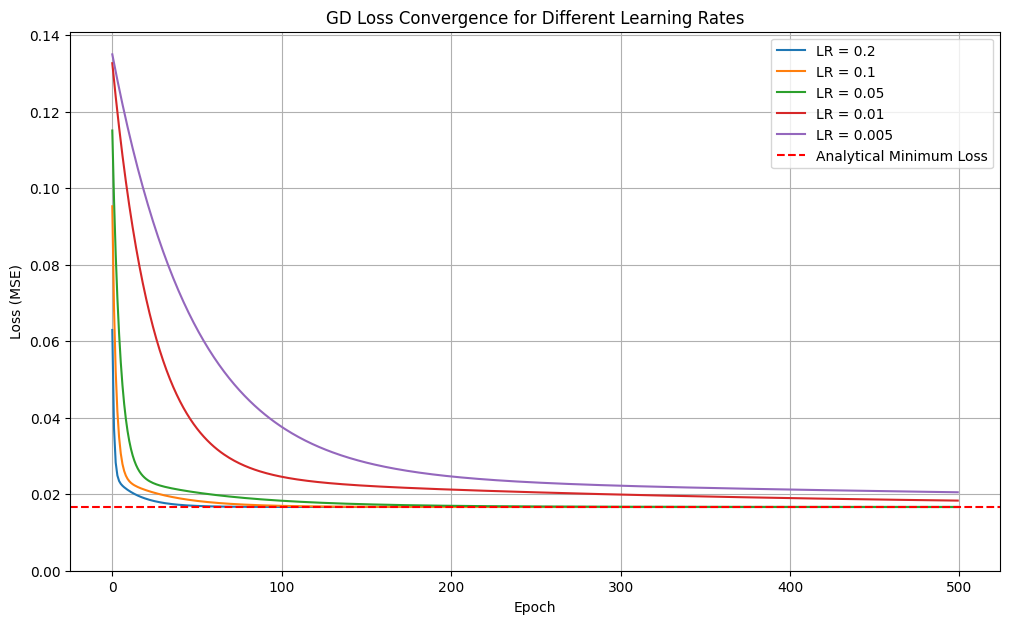

In [40]:
plt.figure(figsize=(12, 7))
for lr, losses in all_losses_by_lr.items():
  plt.plot(losses, label=f'LR = {lr}')

plt.axhline(y=loss_analytical, color='r', linestyle='--', label='Analytical Minimum Loss')
plt.title('GD Loss Convergence for Different Learning Rates')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.ylim(bottom=0) # Ensure y-axis starts at 0 or slightly below min loss
plt.legend()
plt.grid(True)
plt.show()

The plot above clearly shows how the learning rate influences the convergence speed. A very high learning rate (e.g., 0.2) can cause the loss to oscillate or even diverge, while a very low learning rate (e.g., 0.005) leads to very slow convergence, taking many more epochs to reach the minimum. An appropriate learning rate (e.g., 0.05 or 0.01) allows for stable and efficient convergence towards the analytical minimum.

### Additional Epochs for LR=0.005 to Reach Analytical Loss

Let's determine approximately how many more epochs Gradient Descent with a learning rate of `0.005` would need to converge to a loss very close to the analytical minimum.

In [41]:
import copy

# Re-initialize parameters for this specific run
phi0_gd_005 = 0.5
phi1_gd_005 = 0.5
learning_rate_005 = 0.005
max_epochs_005 = 10000 # Set a sufficiently large number of epochs
tolerance = 1e-6 # Define a small tolerance for comparison

losses_gd_005 = []
epochs_to_reach_analytical = -1

print(f"Running GD with Learning Rate: {learning_rate_005} to reach analytical loss ({loss_analytical:.6f})")

for epoch in range(max_epochs_005):
  y_predicted = f(x, phi0_gd_005, phi1_gd_005)
  error = y_predicted - y
  gradient_phi0 = np.mean(error)
  gradient_phi1 = np.mean(error * x)

  phi0_gd_005 = phi0_gd_005 - learning_rate_005 * gradient_phi0
  phi1_gd_005 = phi1_gd_005 - learning_rate_005 * gradient_phi1

  current_loss = compute_loss(x, y, phi0_gd_005, phi1_gd_005)
  losses_gd_005.append(current_loss)

  # Check if the current loss is sufficiently close to the analytical loss
  if abs(current_loss - loss_analytical) < tolerance and epochs_to_reach_analytical == -1:
    epochs_to_reach_analytical = epoch + 1
    print(f"  Loss {current_loss:.6f} reached analytical loss within tolerance at epoch {epochs_to_reach_analytical}")

  if epoch % 1000 == 0 or epoch == max_epochs_005 - 1: # Print progress
    print(f"Epoch {epoch:5d}: Loss = {current_loss:.6f}")

print(f"\nFinal Loss for LR={learning_rate_005} after {max_epochs_005} epochs: {losses_gd_005[-1]:.6f}")

if epochs_to_reach_analytical != -1:
  print(f"Approximately {epochs_to_reach_analytical} epochs were needed for LR={learning_rate_005} to reach the analytical loss (within tolerance {tolerance}).")
  print(f"This is {epochs_to_reach_analytical - 500} additional epochs compared to the initial 500 epochs used for comparison.")
else:
  print(f"Did not reach analytical loss within {max_epochs_005} epochs for LR={learning_rate_005}.")

Running GD with Learning Rate: 0.005 to reach analytical loss (0.016656)
Epoch     0: Loss = 0.134961
Epoch  1000: Loss = 0.018325
Epoch  2000: Loss = 0.016971
Epoch  3000: Loss = 0.016715
Epoch  4000: Loss = 0.016667
Epoch  5000: Loss = 0.016658
  Loss 0.016657 reached analytical loss within tolerance at epoch 5458
Epoch  6000: Loss = 0.016656
Epoch  7000: Loss = 0.016656
Epoch  8000: Loss = 0.016656
Epoch  9000: Loss = 0.016656
Epoch  9999: Loss = 0.016656

Final Loss for LR=0.005 after 10000 epochs: 0.016656
Approximately 5458 epochs were needed for LR=0.005 to reach the analytical loss (within tolerance 1e-06).
This is 4958 additional epochs compared to the initial 500 epochs used for comparison.


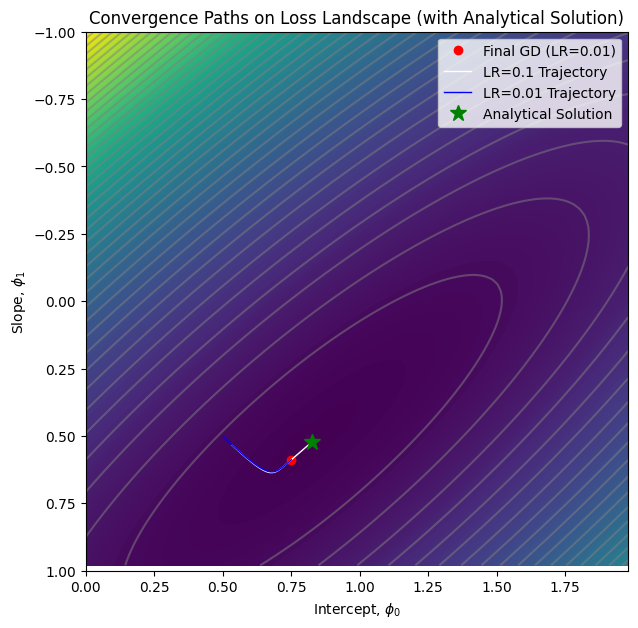

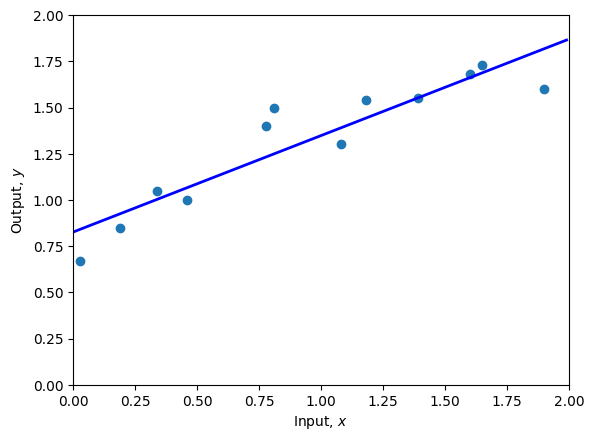

Final Loss with Analytical Solution: 0.0167


In [35]:
# Plot the loss function as a heatmap
fig = plt.figure()
ax = plt.axes()
fig.set_size_inches(7,7)
levels = 256
ax.contourf(phi0_mesh, phi1_mesh, all_losses ,levels)
levels = 40
ax.contour(phi0_mesh, phi1_mesh, all_losses ,levels, colors=['#80808080'])
ax.set_ylim([1,-1])
ax.set_xlabel(r'Intercept, $\phi_0$')
ax.set_ylabel(r'Slope, $\phi_1$')

# Plot the final GD point (from the latest run - LR 0.01)
ax.plot(phi0_gd,phi1_gd,'ro', label='Final GD (LR=0.01)')

# Plot the gradient descent paths
ax.plot(phi0_history_lr01, phi1_history_lr01, 'w-', linewidth=1, label='LR=0.1 Trajectory') # White line for LR=0.1 path
ax.plot(phi0_history_lr001, phi1_history_lr001, 'b-', linewidth=1, label='LR=0.01 Trajectory') # Blue line for LR=0.01 path

# Plot the analytical solution
ax.plot(phi0_analytical, phi1_analytical, 'g*', markersize=12, label='Analytical Solution') # Green star for analytical optimum

plt.legend()
plt.title('Convergence Paths on Loss Landscape (with Analytical Solution)')
plt.show()

# Plot the data with the analytical fit
plot(x, y, phi0_analytical, phi1_analytical)
print(f'Final Loss with Analytical Solution: {loss_analytical:.4f}')

In [38]:
gd_final_loss = losses_gd[-1]
analyze_final_loss = loss_analytical

loss_difference = gd_final_loss - analyze_final_loss

print(f"Final GD Loss (LR=0.01, Epochs=2000): {gd_final_loss:.6f}")
print(f"Analytical Solution Loss: {analyze_final_loss:.6f}")
print(f"New Difference (GD - Analytical): {loss_difference:.6f}")

Final GD Loss (LR=0.01, Epochs=2000): 0.016667
Analytical Solution Loss: 0.016656
New Difference (GD - Analytical): 0.000011


In [29]:
phi0_history_lr01 = phi0_history
phi1_history_lr01 = phi1_history

print("Saved the trajectory for learning rate 0.1.")

Saved the trajectory for learning rate 0.1.


### Comparing Final Loss with Different Epoch Counts

Let's see how the final loss changes as we increase the number of training epochs for our gradient descent algorithm.

In [26]:
# Define a list of epoch counts to test
epoch_counts_to_test = [50, 100, 250, 500, 1000, 2000]

print("Comparing Final Loss for Different Epoch Counts:\n")

for current_epochs in epoch_counts_to_test:
  # Re-initialize parameters for each run to ensure fair comparison
  phi0_compare = 0.5 # Initial guess for intercept
  phi1_compare = 0.5 # Initial guess for slope
  learning_rate = 0.05 # Use the same learning rate

  for epoch in range(current_epochs):
    # Calculate predictions
    y_predicted_compare = f(x, phi0_compare, phi1_compare)

    # Calculate the error
    error_compare = y_predicted_compare - y

    # Calculate gradients
    gradient_phi0_compare = np.mean(error_compare)
    gradient_phi1_compare = np.mean(error_compare * x)

    # Update parameters
    phi0_compare = phi0_compare - learning_rate * gradient_phi0_compare
    phi1_compare = phi1_compare - learning_rate * gradient_phi1_compare

  # Compute final loss for the current epoch count
  final_loss_compare = compute_loss(x, y, phi0_compare, phi1_compare)
  print(f"Epochs: {current_epochs:4d}, Final Loss = {final_loss_compare:.6f}")


Comparing Final Loss for Different Epoch Counts:

Epochs:   50, Final Loss = 0.020490
Epochs:  100, Final Loss = 0.018317
Epochs:  250, Final Loss = 0.016791
Epochs:  500, Final Loss = 0.016658
Epochs: 1000, Final Loss = 0.016656
Epochs: 2000, Final Loss = 0.016656


### Visualize Gradient Descent Path

Let's plot the trajectory of `phi0` and `phi1` on the loss surface and also visualize how the loss decreased over epochs.

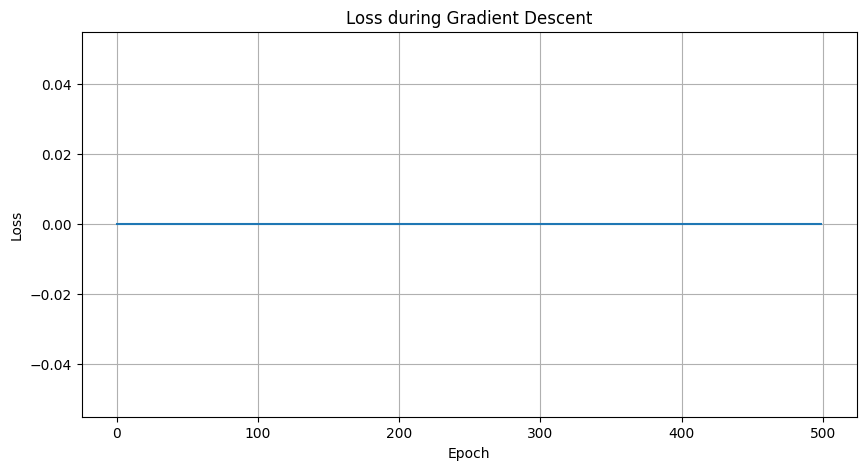

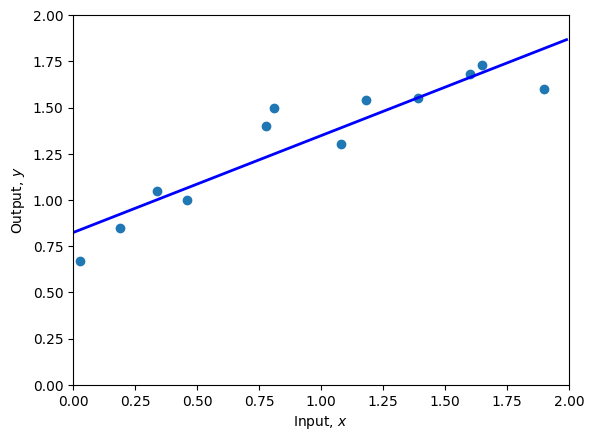

Final Loss with Gradient Descent: 0.00


In [17]:
# Plot the loss over epochs
plt.figure(figsize=(10, 5))
plt.plot(losses_gd)
plt.title('Loss during Gradient Descent')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

# Plot the final fit line
plot(x, y, phi0_gd, phi1_gd)
print(f'Final Loss with Gradient Descent: {compute_loss(x,y,phi0_gd,phi1_gd):3.2f}')